In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("./datasets/winequality-red.csv")

In [3]:
random_state = 719333

# Resolución

## Punto 1

Lea el dataset como un DataFrame de Pandas.

- [x] Realice un estudio de variables.
- [x] Cómo se llaman y que están midiendo exactamente (vea la documentación del dataset).
- [x] Además, analice que tipo de variables (incluido el target) son, cuál es el rango de estas variables y cómo se distribuyen (histograma).
- [x] Además, realice una matriz de correlación, ¿cuáles variables parecen estar correlacionadas? ¿Y con respectos a la calidad del vino?

### Código

In [5]:
df.shape

(1599, 12)

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [20]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
# Analizo outliers por IQR
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    outliers_inf = df[df[col] < (Q1 - 1.5*IQR)][col].count()
    outliers_sup = df[df[col] > (Q1 + 1.5*IQR)][col].count()

    print(f"""Colums: {col}
    IQR inf: {outliers_inf}
    IQR sup: {outliers_sup}""")

Colums: fixed acidity
    IQR inf: 0
    IQR sup: 224
Colums: volatile acidity
    IQR inf: 0
    IQR sup: 139
Colums: citric acid
    IQR inf: 0
    IQR sup: 95
Colums: residual sugar
    IQR inf: 0
    IQR sup: 240
Colums: chlorides
    IQR inf: 9
    IQR sup: 236
Colums: free sulfur dioxide
    IQR inf: 0
    IQR sup: 202
Colums: total sulfur dioxide
    IQR inf: 0
    IQR sup: 238
Colums: density
    IQR inf: 21
    IQR sup: 181
Colums: pH
    IQR inf: 14
    IQR sup: 182
Colums: sulphates
    IQR inf: 0
    IQR sup: 192
Colums: alcohol
    IQR inf: 0
    IQR sup: 183
Colums: quality
    IQR inf: 10
    IQR sup: 217


In [29]:
df["quality"].value_counts()

5    681
6    638
7    199
4     53
8     18
3     10
Name: quality, dtype: int64

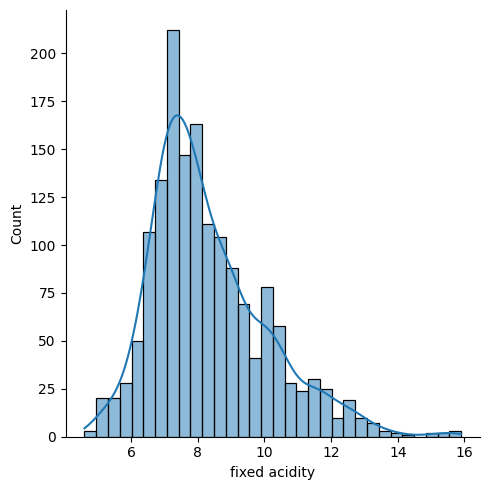

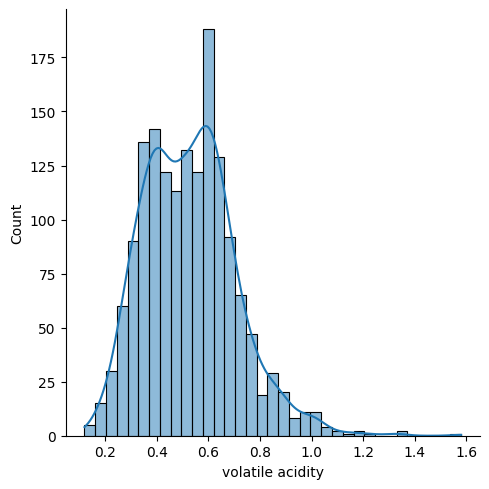

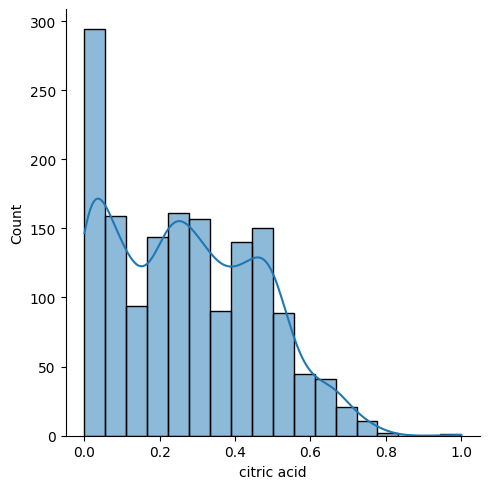

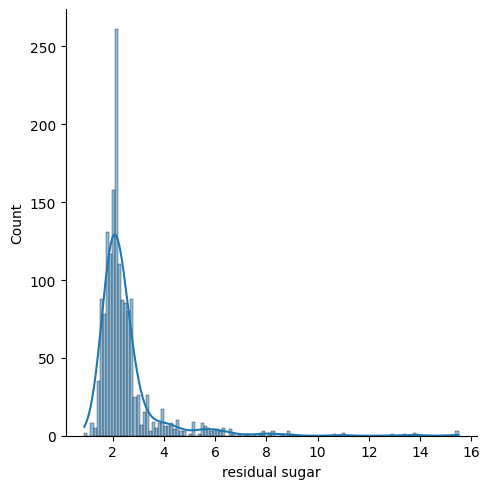

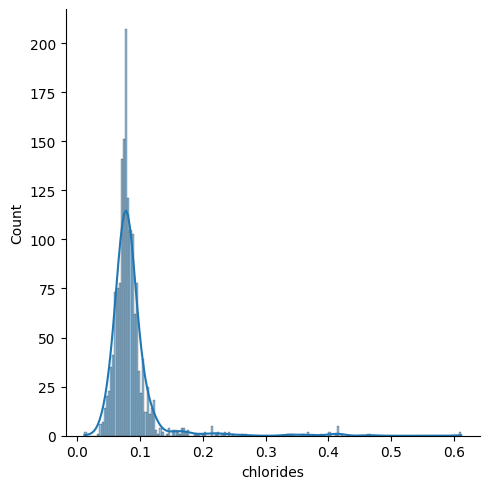

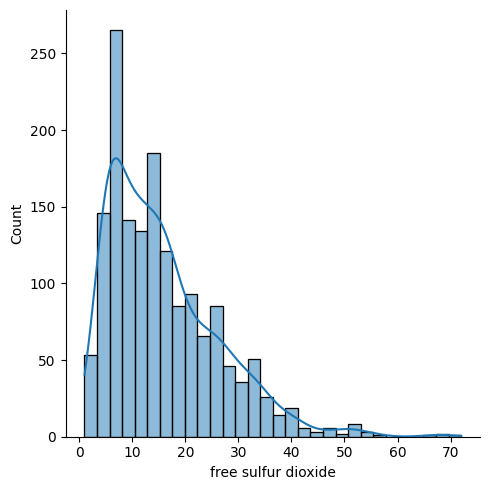

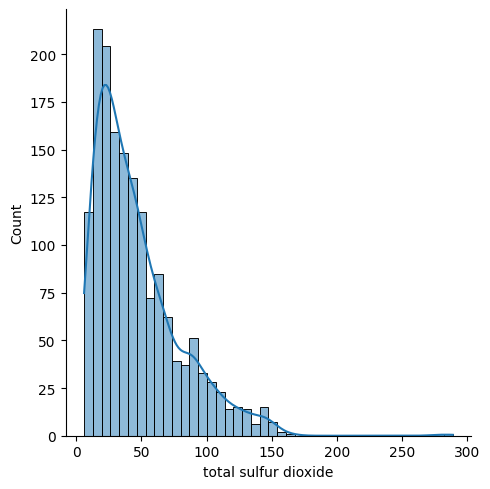

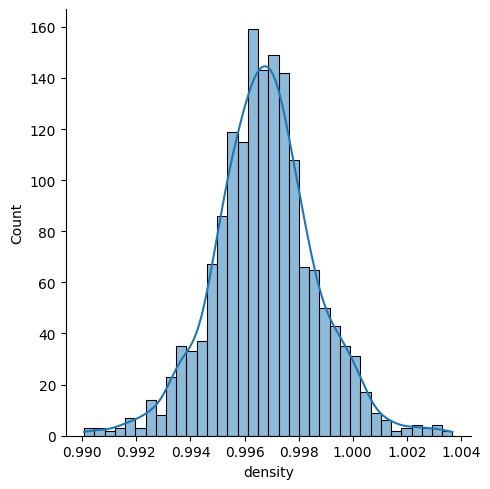

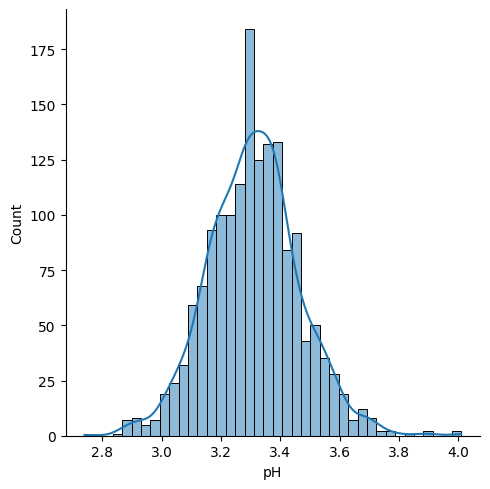

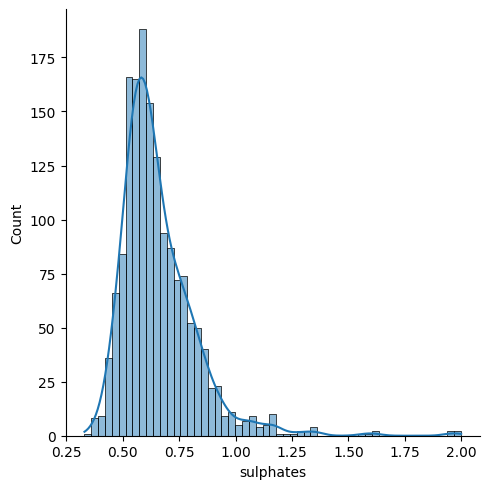

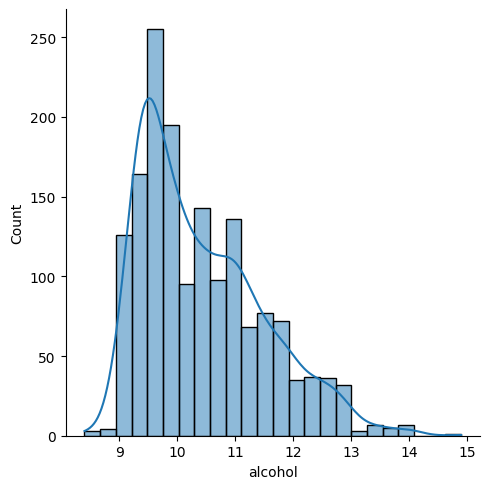

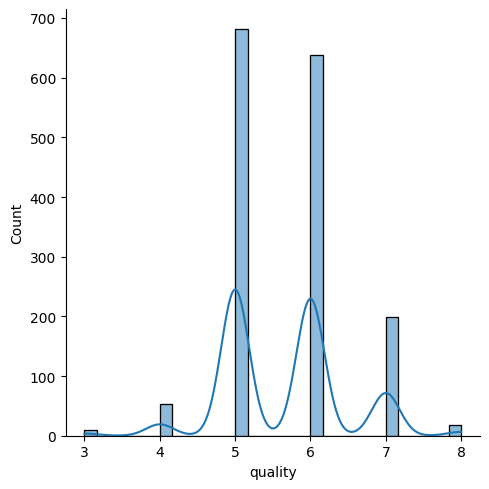

In [13]:
for col in df.columns:
    sns.displot(df[col], kde=True)

<Axes: >

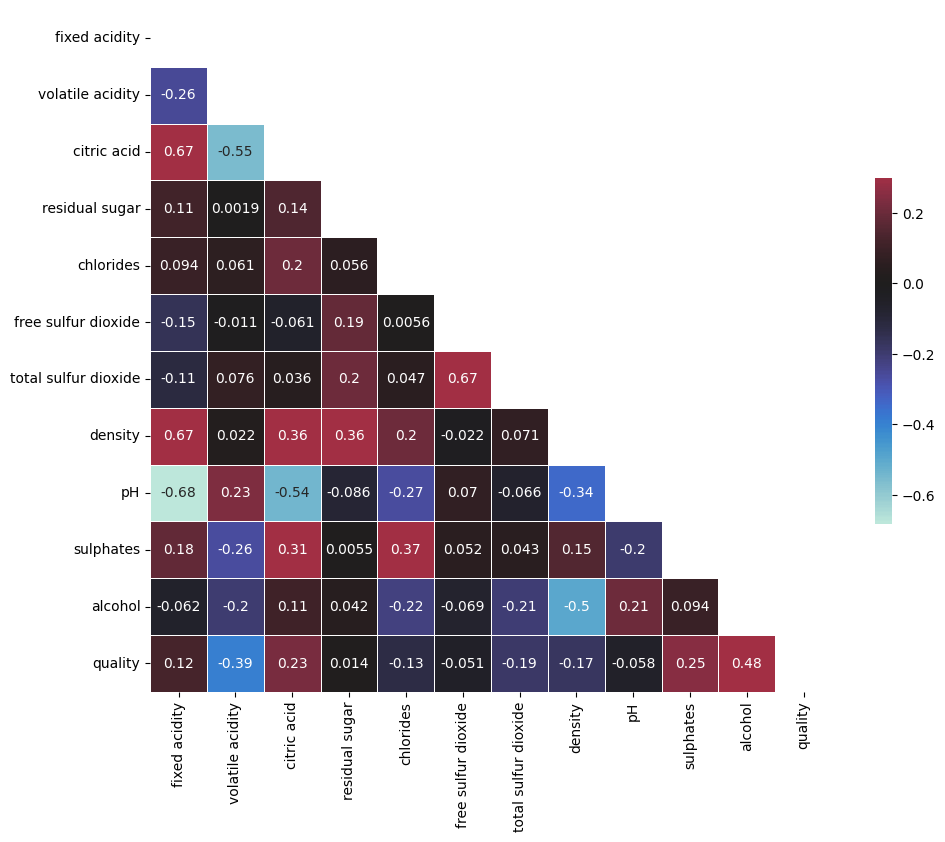

In [19]:
# Compute the correlation matrix
corr = df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
# cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = True)

## Punto 2

Realice si es necesaria la limpieza de datos y corrección de errores.

### Código

In [24]:
# Train-test split
X = df.drop(columns='quality')
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)

In [25]:
# Standard Scaler es ideal para SVM
from sklearn.preprocessing import StandardScaler

# Recordar hacer fit_transform en train y solamente transform en test
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

## Punto 3

Construya usando un SVM un modelo de regresión o clasificación (multi-clase), según lo que considere más apropiado, el cual se intente predecir la calidad del vino usando el nivel de alcohol.

1. [X] Realiza la separación entre el dataset de entrenamiento y testeo. Utilice 80%-20%.
    1. Hecho en punto 2, antes de aplicar un `standard scaler`.
1. [] Determine que métrica se va a usar para evaluar la calidad del modelo (MSE, MAE, etc.)
1. [] Entrene el modelo con el set de entrenamiento.
1. [] Evalúe el modelo con la métrica de evaluación.

In [46]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_classifier = SVC()

grid = GridSearchCV(svm_classifier,
                    [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"], "probability": [True], "decision_function_shape": ["ovr"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "gamma": [0.1, 0.5, 1, 2, 10, 100], "kernel": ["rbf"], "probability": [True], "decision_function_shape": ["ovr"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], "kernel": ["poly"], "probability": [True], "decision_function_shape": ["ovr"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], "kernel": ["sigmoid"], "probability": [True], "decision_function_shape": ["ovr"]}
                     ],
                    refit=True,
                    cv=5,
                    scoring='roc_auc_ovr') # curva roc one versus rest
grid.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"[{'C': [0.01, 0.1, ...], 'decision_function_shape': ['ovr'], 'kernel': ['linear'], 'probability': [True]}, {'C': [0.01, 0.1, ...], 'decision_function_shape': ['ovr'], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf'], ...}, ...]"
,scoring,'roc_auc_ovr'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [47]:
pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_decision_function_shape,param_kernel,param_probability,param_gamma,param_degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
18,0.733485,0.093924,0.079626,0.002783,1.00,ovr,rbf,True,0.1,NaN,"{'C': 1, 'decision_function_shape': 'ovr', 'ga...",0.798089,0.832352,0.808997,0.792529,0.812381,0.808870,0.013762,1
19,1.278577,0.137532,0.069094,0.009142,1.00,ovr,rbf,True,0.5,NaN,"{'C': 1, 'decision_function_shape': 'ovr', 'ga...",0.757914,0.820477,0.821733,0.798882,0.834266,0.806654,0.026896,2
2,0.579159,0.124729,0.027489,0.006539,1.00,ovr,linear,True,NaN,NaN,"{'C': 1, 'decision_function_shape': 'ovr', 'ke...",0.788960,0.806521,0.799335,0.806044,0.794735,0.799119,0.006711,3
5,21.573286,4.609870,0.026068,0.006555,100.00,ovr,linear,True,NaN,NaN,"{'C': 100, 'decision_function_shape': 'ovr', '...",0.779321,0.803037,0.805723,0.792582,0.802789,0.796690,0.009774,4
20,1.449403,0.155161,0.086012,0.033665,1.00,ovr,rbf,True,1.0,NaN,"{'C': 1, 'decision_function_shape': 'ovr', 'ga...",0.781780,0.806009,0.781760,0.803740,0.810055,0.796669,0.012332,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,0.394597,0.017352,0.030617,0.006512,0.01,ovr,poly,True,NaN,4.0,"{'C': 0.01, 'decision_function_shape': 'ovr', ...",0.622257,0.507955,0.672764,0.614554,0.628388,0.609183,0.054513,98
56,0.397142,0.087393,0.023588,0.010059,1.00,ovr,poly,True,NaN,6.0,"{'C': 1, 'decision_function_shape': 'ovr', 'de...",0.735024,0.514100,0.704150,0.532735,0.554301,0.608062,0.092461,99
51,0.381592,0.104667,0.023924,0.010590,0.10,ovr,poly,True,NaN,6.0,"{'C': 0.1, 'decision_function_shape': 'ovr', '...",0.745626,0.395207,0.697038,0.561262,0.631559,0.606138,0.122370,100
71,0.534822,0.145393,0.018380,0.003742,100.00,ovr,poly,True,NaN,6.0,"{'C': 100, 'decision_function_shape': 'ovr', '...",0.708081,0.453472,0.660588,0.487580,0.551177,0.572180,0.097954,101


In [48]:
grid.best_params_

{'C': 1,
 'decision_function_shape': 'ovr',
 'gamma': 0.1,
 'kernel': 'rbf',
 'probability': True}

In [49]:
svm_best_classifier = grid.best_estimator_

In [82]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

y_pred = svm_best_classifier.predict(X_test)

averages = ["micro", "macro", "weighted"]

for avg in averages:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=avg)
    recall = recall_score(y_test, y_pred, average=avg)
    f1 = f1_score(y_test, y_pred, average=avg)

    print("========================================")
    print(f"Average: {avg}")
    print(f"La exactitud de clasificación es: {accuracy}")
    print(f"F1-score de testeo fue: {f1}")
    print(f"Precisión de testeo fue: {precision}")
    print(f"Recall de testeo fue: {recall}")

Average: micro
La exactitud de clasificación es: 0.59375
F1-score de testeo fue: 0.59375
Precisión de testeo fue: 0.59375
Recall de testeo fue: 0.59375
Average: macro
La exactitud de clasificación es: 0.59375
F1-score de testeo fue: 0.2673157435158129
Precisión de testeo fue: 0.27064266829367506
Recall de testeo fue: 0.2716300897170462
Average: weighted
La exactitud de clasificación es: 0.59375
F1-score de testeo fue: 0.5660155889211189
Precisión de testeo fue: 0.5465270363026236
Recall de testeo fue: 0.59375


c:\Users\GasparAcevedo\AppData\Local\pypoetry\Cache\virtualenvs\aprmaqi-ceia-t0YuSKhR-py3.11\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\GasparAcevedo\AppData\Local\pypoetry\Cache\virtualenvs\aprmaqi-ceia-t0YuSKhR-py3.11\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


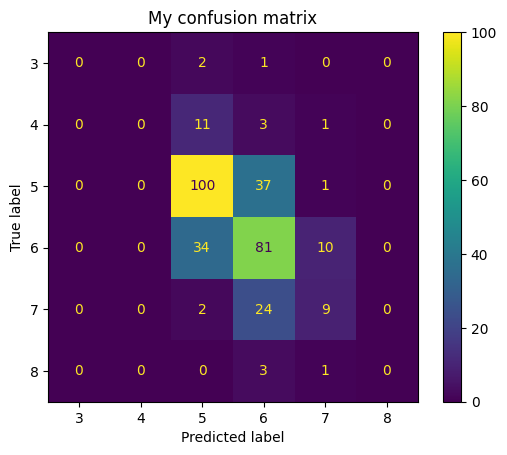

In [89]:
from sklearn.metrics import multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=svm_best_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_best_classifier.classes_)
disp.plot()
plt.title("My confusion matrix")
plt.show()


In [ ]:
# TO-DO: graficar ROC curve para One vs rest
# source: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#one-vs-rest-multiclass-roc